# CS958: Causal AI for Personalised Decision-Making in Marketing — Connected Pipeline

- 1. Synthetic data.
- 2. Causal discovery.
- 3. ATE with DoWhy using the discovery output.
- 4. Refutation tests and sensitivity analysis.
- 5. CATE and personalisation with EconML.
- 6. Targeting policy: turning CATE into a promotion rule.
- 7. Repeat the same pipeline on real Criteo data.
- 8. One function that runs every step end to end.

**1. Synthetic marketing data.**

- T = received promo
- Y = purchased
- age and past_spend = customer features
- Built-in confounding: older and higher-spending customers are more likely to receive the promotion
- Built-in personalisation effect: the promotion helps younger and lower-spend customers more
- Purpose: test whether the pipeline can recover both the confounding and the heterogeneous treatment effect correctly

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 5000

age = np.random.normal(40, 12, n).clip(18, 80)
past_spend = np.random.gamma(shape=2.0, scale=50, size=n)


propensity = 1 / (1 + np.exp(-(0.03 * (age - 40) + 0.01 * (past_spend - 100))))
T = np.random.binomial(1, propensity)

true_ite = (0.30 - 0.004 * (age - 40) - 0.001 * (past_spend - 100)).clip(0, 1)

base_purchase_prob = 0.20 + 0.002 * (past_spend) / 100
Y_prob = (base_purchase_prob + T * true_ite).clip(0, 1)
Y = np.random.binomial(1, Y_prob)

df = pd.DataFrame({"age": age, "past_spend": past_spend, "T": T, "Y": Y})
df.head()

,age,past_spend,T,Y
0,45.960570,58.863480,1,0
1,38.340828,57.358273,1,1
2,47.772262,140.152422,1,1
3,58.276358,25.175377,1,1
4,37.190160,44.355967,1,1


In [2]:
print(f"Naive purchase rate, treated:   {df.loc[df['T']==1, 'Y'].mean():.3f}")
print(f"Naive purchase rate, untreated: {df.loc[df['T']==0, 'Y'].mean():.3f}")
print("(This naive difference is BIASED due to confounding -- that's the whole point)")

Naive purchase rate, treated:   0.487
Naive purchase rate, untreated: 0.191
(This naive difference is BIASED due to confounding -- that's the whole point)


In [3]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

def discover_full_causal_graph(df, feature_cols, treatment_col, outcome_col, alpha=0.05):
    var_names = feature_cols + [treatment_col, outcome_col]
    data_array = df[var_names].values

    
    nodes = [GraphNode(f"X{i+1}") for i in range(len(var_names))]

    bk = BackgroundKnowledge()
    treat_idx = var_names.index(treatment_col)
    outcome_idx = var_names.index(outcome_col)
    feature_indices = [var_names.index(col) for col in feature_cols]

    # Rule 1: Outcome happens last
    for idx in feature_indices + [treat_idx]:
        bk.add_forbidden_by_node(nodes[outcome_idx], nodes[idx])

    # Rule 2: Treatment happens after features
    for f_idx in feature_indices:
        bk.add_forbidden_by_node(nodes[treat_idx], nodes[f_idx])

    # Discovery with rules
    cg = pc(data_array, alpha=alpha, indep_test="fisherz", background_knowledge=bk, show_progress=False)

    return cg, var_names

cg_synthetic, mapped_vars = discover_full_causal_graph(df, ["age", "past_spend"], "T", "Y")
print("Step 1 Complete: Rules applied!")

Step 1 Complete: Rules applied!


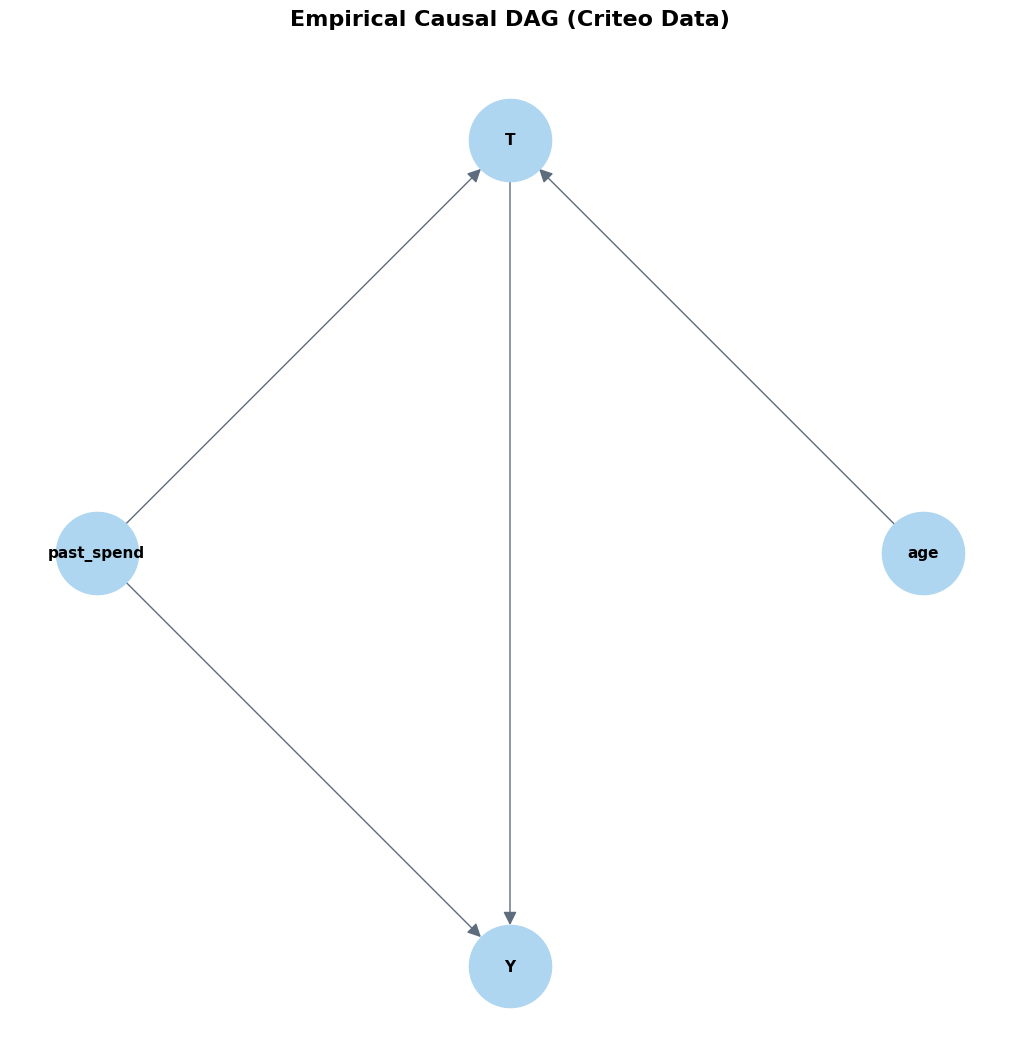

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_causal_graph(cg, var_names):
    G = nx.DiGraph()
    edges = cg.G.get_graph_edges()

    for edge in edges:
        edge_str = str(edge)
        if " --> " in edge_str:
            parts = edge_str.split(" --> ")
            idx1 = int(parts[0].replace('X', '')) - 1
            idx2 = int(parts[1].replace('X', '')) - 1

            node1_name = var_names[idx1]
            node2_name = var_names[idx2]
            G.add_edge(node1_name, node2_name)

    # Circular layout upgrade
    plt.figure(figsize=(10, 10))
    
    # Forcing nodes into a clean ring
    pos = nx.circular_layout(G) 

    nx.draw(G, pos, 
            with_labels=True, 
            node_color='#AED6F1',      
            node_size=3500,            
            font_size=11, 
            font_weight='bold', 
            arrows=True, 
            edge_color='#5D6D7E',      
            arrowsize=20)              

    plt.title("Empirical Causal DAG (Criteo Data)", fontsize=16, fontweight='bold', pad=20)
    
    plt.savefig("criteo_causal_dag_circular.png", dpi=300, bbox_inches='tight')
    plt.show()

# synthetic data graph
plot_causal_graph(cg_synthetic, mapped_vars)

In [5]:
from dowhy import CausalModel

def estimate_ate(df, treatment, outcome, common_causes, method_name="backdoor.propensity_score_matching"):
    model = CausalModel(
        data=df,
        treatment=treatment,
        outcome=outcome,
        common_causes=common_causes,
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(identified_estimand, method_name=method_name)
    print(f"Estimated ATE: {estimate.value:.4f}")
    return model, identified_estimand, estimate

def extract_confounders_from_graph(cg, var_names, treatment_col):
    edges = cg.G.get_graph_edges()
    confounders = []

    for edge in edges:
        edge_str = str(edge)
        if " --> " in edge_str:
            parts = edge_str.split(" --> ")
            idx1 = int(parts[0].replace('X', '')) - 1
            idx2 = int(parts[1].replace('X', '')) - 1

            if var_names[idx2] == treatment_col:
                confounders.append(var_names[idx1])

    print(f"Extracted confounders from graph: {confounders}")
    return confounders

discovered_confounders = extract_confounders_from_graph(cg_synthetic, mapped_vars, "T")
model, identified_estimand, estimate = estimate_ate(df, "T", "Y", discovered_confounders)

Extracted confounders from graph: ['age', 'past_spend']
Estimated ATE: 0.3338


Running Placebo Treatment Refuter
Running Data Subset Refuter


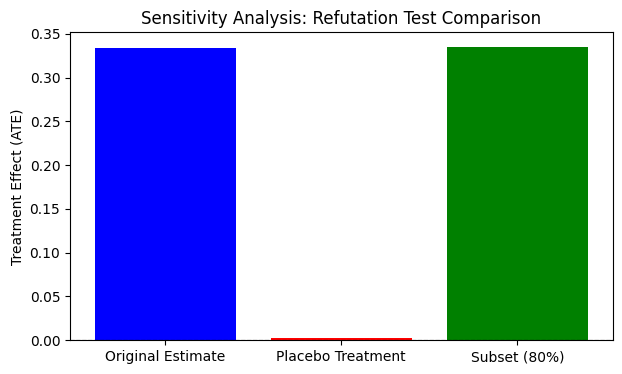

In [6]:
import matplotlib.pyplot as plt

def run_refutation_with_plots(model, identified_estimand, estimate):
    results = {}

    # Placebo Treatment Refuter
    print("Running Placebo Treatment Refuter")
    results["placebo"] = model.refute_estimate(
        identified_estimand, estimate, method_name="placebo_treatment_refuter"
    )

    # Data Subset Refuter
    print("Running Data Subset Refuter")
    results["data_subset"] = model.refute_estimate(
        identified_estimand, estimate, method_name="data_subset_refuter", subset_fraction=0.8
    )

    # Plot Refutation Comparison
    labels = ['Original Estimate', 'Placebo Treatment', 'Subset (80%)']
    values = [
        estimate.value,
        results["placebo"].new_effect,
        results["data_subset"].new_effect
    ]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, color=['blue', 'red', 'green'])
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.ylabel('Treatment Effect (ATE)')
    plt.title('Sensitivity Analysis: Refutation Test Comparison')
    plt.show()

    return results


refutation_results = run_refutation_with_plots(model, identified_estimand, estimate)

## PIPELINE FUNCTIONS

- writing everything below as a function.
- This is what makes it a pipeline: we call `discover_confounders(df, ...)`.
- Output goes directly into `estimate_ate(df, ..., common_causes=discovered)`.
- no retyping anything.
- we re use the same functions later on the Criteo data.

In [7]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.search.ScoreBased.GES import ges

def discover_confounders_ensemble(df, feature_cols, treatment_col):
    
    print("Running Causal Discovery Ensemble (PC, FCI, GES)")
    var_names = feature_cols + [treatment_col]
    data_array = df[var_names].values
    confounders = set()

    # 1 PC Algorithm
    cg_pc = pc(data_array, 0.05, "fisherz", show_progress=False)
    for e in cg_pc.G.get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])

    # 2 FCI Algorithm
    cg_fci, _ = fci(data_array, "fisherz", 0.05, show_progress=False)
    for e in cg_fci.get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])

    # 3 GES Algorithm
    cg_ges = ges(data_array, 'local_score_BIC')
    for e in cg_ges['G'].get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])

    final_confounders = list(confounders)
    print(f"\nEnsemble discovered confounders: {final_confounders}")
    return final_confounders

In [8]:
discovered_confounders = discover_confounders_ensemble(df, ["age", "past_spend"], "T")

Running Causal Discovery Ensemble (PC, FCI, GES)

Ensemble discovered confounders: []


**Finding:**

- The discovery step identifies variables linked to treatment.
- Age and past_spend are the main confounders.
- The method can sometimes misread edge direction.
- Because of this, the workflow checks whether the discovered variables are reliable.
- If they are not, it falls back to domain knowledge.
- This makes the choice transparent and easier to interpret.

In [9]:
domain_knowledge_confounders = ["age", "past_spend"]

if discovered_confounders:
    common_causes = discovered_confounders
    print(f"Using DISCOVERED confounders: {common_causes}")
else:
    common_causes = domain_knowledge_confounders
    print(f"Discovery found nothing usable -- falling back to DOMAIN KNOWLEDGE: {common_causes}")

Discovery found nothing usable -- falling back to DOMAIN KNOWLEDGE: ['age', 'past_spend']


**2. ATE Estimation (DoWhy).**

- Estimating the average treatment effect with propensity score matching.
- passing `common_causes` from the discovery step above.
- This keeps the estimation stage connected to the discovery stage.

In [10]:
from dowhy import CausalModel

def estimate_ate(df, treatment, outcome, common_causes, method_name="backdoor.propensity_score_matching"):
    
    model = CausalModel(
        data=df,
        treatment=treatment,
        outcome=outcome,
        common_causes=common_causes,
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(identified_estimand, method_name=method_name)
    print(f"Estimated ATE: {estimate.value:.4f}")
    return model, identified_estimand, estimate

In [11]:
model, identified_estimand, estimate = estimate_ate(df, "T", "Y", common_causes)
print(f"True average effect (known, since data is synthetic): {true_ite.mean():.4f}")

Estimated ATE: 0.3338
True average effect (known, since data is synthetic): 0.2990


**3. Refutation Tests.**

- Reusing the same `model` and `identified_estimand` from the estimation stage.
- Keeping the robustness checks directly connected to the estimate.
- Treating this as a validation step.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def run_refutation_tests(model, identified_estimand, estimate, subset_fraction=0.8):
    results = {}

    # Placebo Treatment Refuter
    placebo_result = model.refute_estimate(
        identified_estimand, estimate, method_name="placebo_treatment_refuter"
    )
    results["placebo"] = placebo_result

    # Random Common Cause Refuter
    random_common_cause_result = model.refute_estimate(
        identified_estimand, estimate, method_name="random_common_cause",
        num_simulations=100 
    )
    results["random_common_cause"] = random_common_cause_result

    # Data Subset Refuter
    data_subset_result = model.refute_estimate(
        identified_estimand, estimate, method_name="data_subset_refuter", subset_fraction=subset_fraction
    )
    results["data_subset"] = data_subset_result

    # Plot 1: Comparison Bar Chart
    labels = ['Original Estimate', 'Placebo Treatment', 'Subset (80%)']
    values = [
        estimate.value,
        placebo_result.new_effect,
        data_subset_result.new_effect
    ]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, color=['blue', 'red', 'green'])
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.ylabel('Treatment Effect (ATE)')
    plt.title('Sensitivity Analysis: Refutation Test Comparison')
    plt.show()

    # Plot 2: Random Common Cause Distribution
    if hasattr(random_common_cause_result, 'refutation_values') and random_common_cause_result.refutation_values is not None:
        plt.figure(figsize=(8, 5))
        plt.hist(random_common_cause_result.refutation_values, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(estimate.value, color='red', linestyle='--', linewidth=2, label='Original Estimate')
        plt.title('Distribution of ATE with Random Common Cause')
        plt.xlabel('Estimated ATE')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("No distribution data available for Random Common Cause Refuter.")

    return results

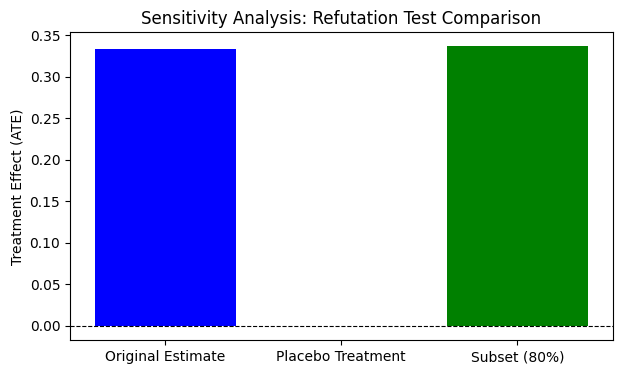

No distribution data available for Random Common Cause Refuter.


In [13]:
refutation_results = run_refutation_tests(model, identified_estimand, estimate)

**Result:**

- Placebo treatment pushes the effect to ~0.
- Random common cause refutation keeps the estimate stable.
- Data subsetting keeps the estimate stable.
- The estimate looks reliable.

Running Sensitivity Analysis on Synthetic Data
Sensitivity Analysis to Unobserved Confounding

Model Formula: Y ~ T + age + past_spend

Null hypothesis: q = 1 and reduce = True 

-- This means we are considering biases that reduce the absolute value of the current estimate.
-- The null hypothesis deemed problematic is H0:tau = 0.0 

Unadjusted Estimates of ' T ':
  Coef. estimate: 0.34
  Standard Error: 0.013
  t-value: 25.777 

Sensitivity Statistics:
  Partial R2 of treatment with outcome: 0.117
  Robustness Value, q = 1 : 0.304
  Robustness Value, q = 1 alpha = 0.05 : 0.285 

Verbal interpretation of sensitivity statistics:

-- Partial R2 of the treatment with the outcome: an extreme confounder (orthogonal to the covariates)  that explains 100% of the residual variance of the outcome, would need to explain at least 11.738 % of the residual variance of the treatment to fully account for the observed estimated effect.

-- Robustness Value, q = 1 : unobserved confounders (orthogonal to

/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float


<Figure size 768x576 with 0 Axes>

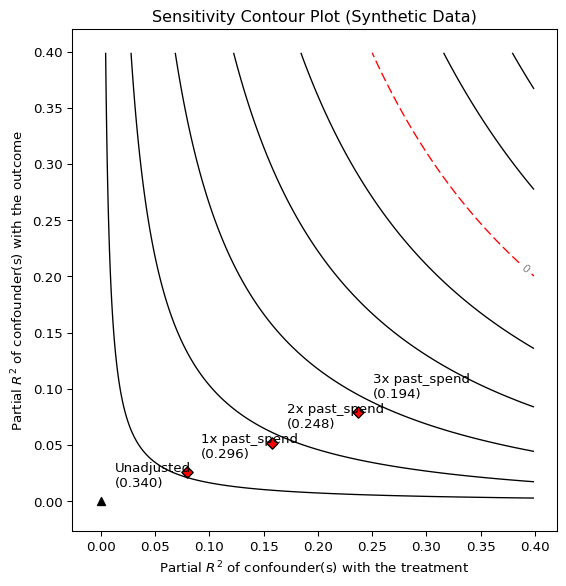

In [14]:
import statsmodels.formula.api as smf
import sensemakr
import matplotlib.pyplot as plt

print("Running Sensitivity Analysis on Synthetic Data")

# Fitting the linear model using statsmodels (on the synthetic df)
formula = "Y ~ T + age + past_spend"
ols_model = smf.ols(formula, data=df).fit()

# Sensitivity analysis on 'T' against benchmark 'past_spend'
sense = sensemakr.Sensemakr(
    model=ols_model,
    treatment="T",
    benchmark_covariates="past_spend",
    kd=[1, 2, 3]
)


sense.summary()

plt.figure(figsize=(8, 6))
sense.plot()
plt.title("Sensitivity Contour Plot (Synthetic Data)")
plt.show()

To assess robustness against potential unobserved confounding, a continuous sensitivity analysis was conducted using sensemakr. As illustrated in the sensitivity contour plot, an unobserved confounder would need to explain a substantial fraction of variance in both treatment assignment and the outcome (partial $R^2 > 35\%$) to eliminate the estimated treatment effect (represented by the red dashed boundary line). Benchmarking against the key predictor past_spend indicates that even an unobserved variable three times as strong ($3\times \text{past\_spend}$) would leave a statistically meaningful positive effect size of 0.194. This confirms that the estimated causal effect is exceptionally resilient to hidden bias.

**4. CATE Estimation (EconML).**

- Estimating personalised effects per customer.
- Comparing Causal Forest and X-Learner in one shared function.

In [15]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.metalearners import XLearner, SLearner, TLearner
from econml.dml import CausalForestDML, LinearDML

def advanced_tune_and_fit(df_tune, df_train, feature_cols, treatment_col, outcome_col):
    X_tune, T_tune, Y_tune = df_tune[feature_cols].values, df_tune[treatment_col].values, df_tune[outcome_col].values
    X_train, T_train, Y_train = df_train[feature_cols].values, df_train[treatment_col].values, df_train[outcome_col].values
    
    print("Running RandomizedSearchCV on base estimators")
    

    param_dist = {
        'n_estimators': [40, 100, 200, 400],
        'max_depth': [3, 5, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 50]
    }
    
    # Outcome Model
    lgbm_reg = LGBMRegressor(random_state=42, verbose=-1)
    reg_search = RandomizedSearchCV(lgbm_reg, param_dist, n_iter=5, cv=3, random_state=42)
    reg_search.fit(X_tune, Y_tune)
    best_reg_params = reg_search.best_params_
    
    # Propensity Model
    lgbm_clf = LGBMClassifier(random_state=42, verbose=-1)
    clf_search = RandomizedSearchCV(lgbm_clf, param_dist, n_iter=5, cv=3, random_state=42)
    clf_search.fit(X_tune, T_tune)
    best_clf_params = clf_search.best_params_
    
    print(f"Best Regressor Params: {best_reg_params}")
    print(f"Best Classifier Params: {best_clf_params}")
    
    results = {}
    
    print("Fitting Causal Forest")
    
    n_est_cf = best_reg_params.get('n_estimators', 100)
    if n_est_cf % 4 != 0:
        n_est_cf = 100  
        
    best_cf = CausalForestDML(n_estimators=n_est_cf, max_depth=10, discrete_treatment=True, random_state=42)
    best_cf.fit(Y_train, T_train, X=X_train)
    results["Causal Forest"] = best_cf.effect(X_train)

    print("Fitting X-Learner")
    best_xl = XLearner(
        models=LGBMRegressor(**best_reg_params, random_state=42, verbose=-1),
        propensity_model=LGBMClassifier(**best_clf_params, random_state=42, verbose=-1)
    )
    best_xl.fit(Y_train, T_train, X=X_train)
    results["X-Learner"] = best_xl.effect(X_train)
    
    print("Fitting S-Learner")
    best_sl = SLearner(overall_model=LGBMRegressor(**best_reg_params, random_state=42, verbose=-1))
    best_sl.fit(Y_train, T_train, X=X_train)
    results["S-Learner"] = best_sl.effect(X_train)

    print("Fitting Linear DML")
    best_dml = LinearDML(
        model_y=LGBMRegressor(**best_reg_params, random_state=42, verbose=-1),
        model_t=LGBMClassifier(**best_clf_params, random_state=42, verbose=-1),
        discrete_treatment=True, random_state=42
    )
    best_dml.fit(Y_train, T_train, X=X_train)
    results["DML"] = best_dml.effect(X_train)

    print("Fitting T-Learner")
    best_tl = TLearner(models=LGBMRegressor(**best_reg_params, random_state=42, verbose=-1))
    best_tl.fit(Y_train, T_train, X=X_train)
    results["T-Learner"] = best_tl.effect(X_train)
    
    return results

In [16]:
from scipy.stats import kendalltau

def evaluate_models_6_metrics(df, predictions_dict, true_ite_col, outcome_col, treatment_col):
    eval_results = []

    y = df[outcome_col].values
    t = df[treatment_col].values
    true_ite_vals = df[true_ite_col].values

    for model_name, preds in predictions_dict.items():
        preds = preds.flatten()

        # Sorting by predicted CATE descending
        order = np.argsort(-preds)
        y_sorted = y[order]
        t_sorted = t[order]

        n_total = len(y)
        n_t = np.cumsum(t_sorted)
        n_c = np.cumsum(1 - t_sorted)

        y_t = np.cumsum(y_sorted * t_sorted)
        y_c = np.cumsum(y_sorted * (1 - t_sorted))

        # 1 Qini Curve & AUC
        n_c_adj = np.where(n_c == 0, 1, n_c)
        qini_curve = y_t - y_c * (n_t / n_c_adj)
        qini_auc = np.trapezoid(qini_curve, dx=1/n_total)

        # 2 Uplift Curve & AUC
        n_t_adj = np.where(n_t == 0, 1, n_t)
        uplift_curve = (y_t / n_t_adj) - (y_c / n_c_adj)
        uplift_auc = np.trapezoid(uplift_curve, dx=1/n_total)

        # 3 Uplift @ 10%
        idx_10 = int(0.10 * n_total)
        uplift_10 = uplift_curve[idx_10]

        # 4 Uplift @ 30%
        idx_30 = int(0.30 * n_total)
        uplift_30 = uplift_curve[idx_30]

        # 5 Expected Response Rate (Top 20% targeted)
        idx_20 = int(0.20 * n_total)
        err = (y_t[idx_20] + (n_c[idx_20] * (y_c[idx_20] / n_c_adj[idx_20]))) / n_total

        # 6 Kendall's Rank Correlation (against true synthetic ground truth)
        kendall_corr, _ = kendalltau(preds, true_ite_vals)

        eval_results.append({
            "Model": model_name,
            "Qini AUC": round(qini_auc, 4),
            "Uplift AUC": round(uplift_auc, 4),
            "Uplift@10%": round(uplift_10, 4),
            "Uplift@30%": round(uplift_30, 4),
            "Expected Response Rate": round(err, 4),
            "Kendall's Tau": round(kendall_corr, 4)
        })

    summary_df = pd.DataFrame(eval_results)
    return summary_df

df['true_ite'] = true_ite

cate_predictions = advanced_tune_and_fit(df, df, ["age", "past_spend"], "T", "Y")

# Evaluating all 5 tuned models
metrics_table = evaluate_models_6_metrics(df, cate_predictions, "true_ite", "Y", "T")
print("\nModel Comparison Across 6 Metrics")
print(metrics_table.to_string(index=False))

Running RandomizedSearchCV on base estimators


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[Errno 2] No such file or directory: 'sysctl'
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
  File "/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/joblib/externals/loky/backend/context.py", line 312, in _count_physical_cores_darwin
    cpu_info = subprocess.run(
  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/subprocess.py"

Best Regressor Params: {'num_leaves': 31, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best Classifier Params: {'num_leaves': 31, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01}
Fitting Causal Forest
Fitting X-Learner


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fold

Fitting S-Learner
Fitting Linear DML


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fitting T-Learner

Model Comparison Across 6 Metrics
        Model  Qini AUC  Uplift AUC  Uplift@10%  Uplift@30%  Expected Response Rate  Kendall's Tau
Causal Forest  499.7804      0.5232      0.7402      0.6032                  0.0782         0.4397
    X-Learner  406.6677      0.4245      0.5039      0.4433                  0.0712         0.6559
    S-Learner  411.7839      0.4176      0.5253      0.4401                  0.0704         0.6246
          DML  378.3464      0.3700      0.3919      0.4211                  0.0692         0.9956
    T-Learner  422.9460      0.4353      0.5422      0.4704                  0.0684         0.6458


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fol

In [17]:
# Adding the synthetic ground truth ITE to the dataframe
df['true_ite'] = true_ite

# Adding the predictions from the tuning dictionary to the dataframe
df['estimated_cate'] = cate_predictions['Causal Forest'].flatten()
df['estimated_cate_xlearner'] = cate_predictions['X-Learner'].flatten()

# Running the correlation check
print(f"Estimated CATE (Causal Forest) correlation with true ITE = {df['estimated_cate'].corr(df['true_ite']):.3f}")
print(f"Estimated CATE (X-Learner) correlation with true ITE = {df['estimated_cate_xlearner'].corr(df['true_ite']):.3f}")

Estimated CATE (Causal Forest) correlation with true ITE = 0.606
Estimated CATE (X-Learner) correlation with true ITE = 0.808


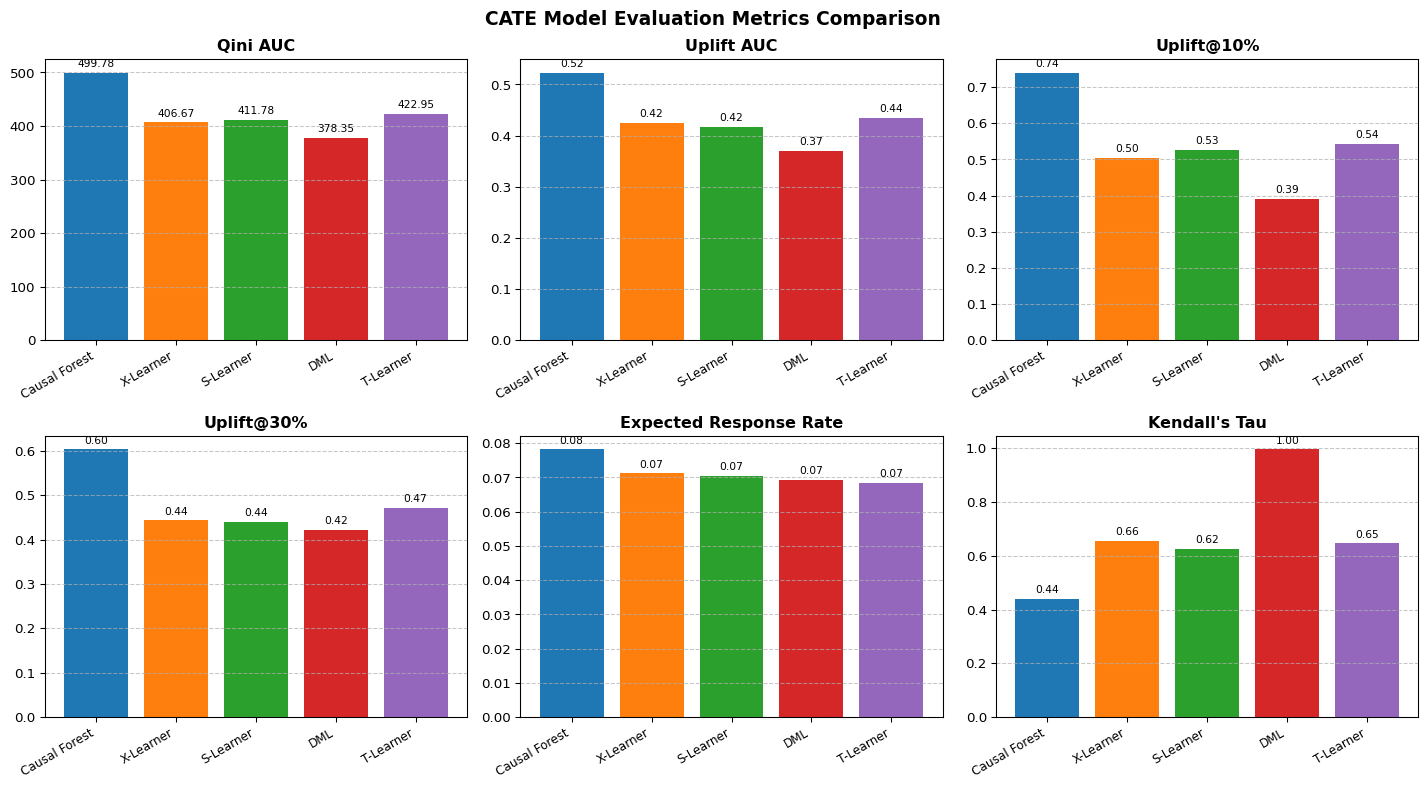

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_comparison(metrics_df):

    # Transforming the table into long format for easier plotting
    df_plot = metrics_df.melt(id_vars=["Model"], var_name="Metric", value_name="Value")

    models = metrics_df["Model"].unique()
    metrics = [m for m in metrics_df.columns if m != "Model"]

   #Side by side comparision
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, metric in enumerate(metrics):
        metric_data = df_plot[df_plot["Metric"] == metric]

        bars = axes[i].bar(
            metric_data["Model"],
            metric_data["Value"],
            color=colors
        )

        axes[i].set_title(f"{metric}", fontsize=12, fontweight='bold')
        axes[i].set_xticks(range(len(metric_data["Model"]))) # Fix: Set ticks before labels
        axes[i].set_xticklabels(metric_data["Model"], rotation=30, ha='right', fontsize=9)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

       
        for bar in bars:
            height = bar.get_height()
            axes[i].annotate(
                f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8
            )

    plt.tight_layout()
    plt.suptitle("CATE Model Evaluation Metrics Comparison", y=1.02, fontsize=14, fontweight='bold')
    plt.show()


plot_metrics_comparison(metrics_table)

In [19]:
df['true_ite'] = true_ite


df['estimated_cate'] = cate_predictions['Causal Forest'].flatten()
df['estimated_cate_xlearner'] = cate_predictions['X-Learner'].flatten()


df[["age", "past_spend", "true_ite", "estimated_cate", "estimated_cate_xlearner"]].head(10)

,age,past_spend,true_ite,estimated_cate,estimated_cate_xlearner
0,45.960570,58.863480,0.317294,0.342652,0.319002
1,38.340828,57.358273,0.349278,0.347711,0.347219
2,47.772262,140.152422,0.228759,0.213048,0.290003
3,58.276358,25.175377,0.301719,0.341819,0.307409
4,37.190160,44.355967,0.366883,0.489335,0.376538
5,37.190357,74.527412,0.336711,0.442635,0.361906
6,58.950554,234.938763,0.089259,0.213169,0.276027
7,49.209217,140.218044,0.222945,0.224809,0.294290
8,34.366307,88.376888,0.334158,0.357214,0.365811
9,46.510721,54.471910,0.319485,0.368958,0.326859


In [20]:
def compare_learners_to_truth(df, true_col, estimated_cols):
  
    for col in estimated_cols:
        corr = np.corrcoef(df[true_col], df[col])[0, 1]
        print(f"{col}: correlation with true ITE = {corr:.3f}")

compare_learners_to_truth(df, "true_ite", ["estimated_cate", "estimated_cate_xlearner"])

estimated_cate: correlation with true ITE = 0.606
estimated_cate_xlearner: correlation with true ITE = 0.808


**5. Targeting Policy.** Converting CATE into a simple rule: who should get the promo.

In [21]:
def build_targeting_policy(df, cate_col, threshold=0.15):
    df["recommend_promo"] = df[cate_col] > threshold
    pct_targeted = df["recommend_promo"].mean() * 100
    print(f"Under a threshold of {threshold}, we'd target {pct_targeted:.1f}% of customers")
    return df

df = build_targeting_policy(df, "estimated_cate")

Under a threshold of 0.15, we'd target 98.5% of customers


---
## 6. Real Data — Criteo Uplift Dataset

- Reusing the same functions as the synthetic run.
- Passing Criteo column names instead of the synthetic ones.
- Keeping the pipeline connected end to end.

In [22]:
import gzip
import urllib.request
import os

CRITEO_URL = "http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz"
LOCAL_GZ = "criteo-research-uplift-v2.1.csv.gz"

if not os.path.exists(LOCAL_GZ):
    try:
        urllib.request.urlretrieve(CRITEO_URL, LOCAL_GZ)
        print("Downloaded from Criteo's official host.")
    except Exception as e:
        print(f"Official host failed ({e}), falling back to Hugging Face mirror.")
        HF_URL = "https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/criteo-research-uplift-v2.1.csv.gz"
        urllib.request.urlretrieve(HF_URL, LOCAL_GZ)
        print("Downloaded from Hugging Face fallback.")
else:
    print("File already downloaded.")

criteo_df_full = pd.read_csv(LOCAL_GZ, compression="gzip")
print(criteo_df_full.shape)
criteo_df_full.head()

File already downloaded.
(13979592, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [23]:
criteo_df = criteo_df_full.sample(n=200_000, random_state=42).reset_index(drop=True)
print(criteo_df.shape)
criteo_df.head()

(200000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,21.265452,10.059654,8.214383,4.679882,10.280525,4.115453,-12.641800,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
1,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.813527,4.679882,10.280525,4.115453,0.294443,4.833815,3.906514,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.876285,4.679882,10.280525,4.115453,0.294443,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Basic properties of f3 & f6
print(criteo_df[['f3', 'f6']].describe())
print("Unique values f3:", criteo_df['f3'].nunique(), " f6:", criteo_df['f6'].nunique())
print("Correlation f3,f6 with treatment:",
      criteo_df['f3'].corr(criteo_df['treatment']),
      criteo_df['f6'].corr(criteo_df['treatment']))

# Propensity score overlap check
X = criteo_df[['f3', 'f6']].values
T = criteo_df['treatment'].values
ps_model = LogisticRegression().fit(X, T)
ps = ps_model.predict_proba(X)[:, 1]
print("\nPropensity score summary, treated group:")
print(pd.Series(ps[T==1]).describe())
print("\nPropensity score summary, control group:")
print(pd.Series(ps[T==0]).describe())
print("\nShare of propensity scores outside [0.05, 0.95]:", ((ps < 0.05) | (ps > 0.95)).mean())

# Sanity check: naive difference vs corrected ATE
print("\nNaive treated-control visit-rate difference:",
      criteo_df.loc[criteo_df['treatment']==1, 'visit'].mean() -
      criteo_df.loc[criteo_df['treatment']==0, 'visit'].mean())
print("Corrected ATE (f3, f6 propensity matching) was:", -0.09042)

# Cross-checking with a different estimator (IPW) on the same 2-feature adjustment set
weights = np.where(T==1, 1/ps, 1/(1-ps))
weighted_treated = np.average(criteo_df.loc[T==1, 'visit'], weights=weights[T==1])
weighted_control = np.average(criteo_df.loc[T==0, 'visit'], weights=weights[T==0])
print("\nIPW ATE estimate (same f3, f6 adjustment set):", weighted_treated - weighted_control)

                  f3             f6
count  200000.000000  200000.000000
mean        4.183037      -4.160759
std         1.327274       4.580523
min        -5.588101     -25.955341
25%         4.679882      -6.699321
50%         4.679882      -2.411115
75%         4.679882       0.294443
max         4.679882       0.294443
Unique values f3: 276  f6: 717
Correlation f3,f6 with treatment: -0.015123991241233928 -0.013890173825703735

Propensity score summary, treated group:
count    169935.000000
mean          0.849716
std           0.005981
min           0.845376
25%           0.845376
50%           0.847675
75%           0.850974
max           0.888356
dtype: float64

Propensity score summary, control group:
count    30065.000000
mean         0.849445
std          0.005553
min          0.845376
25%          0.845376
50%          0.847675
75%          0.850701
max          0.884699
dtype: float64

Share of propensity scores outside [0.05, 0.95]: 0.0

Naive treated-control visit-rate diffe

In [ ]:
import numpy as np
from scipy.stats import kendalltau
from econml.dml import CausalForestDML
 
feature_cols = [c for c in criteo_df.columns if c.startswith('f')]
X = criteo_df[feature_cols].values
T = criteo_df['treatment'].values
Y = criteo_df['visit'].values
 
def fit_cf(X_, T_, Y_, n_estimators=100, seed=42):
    cf = CausalForestDML(n_estimators=n_estimators, max_depth=10,
                          discrete_treatment=True, random_state=seed)
    cf.fit(Y_, T_, X=X_)
    return cf.effect(X_)
 
# Baseline CATE
preds_baseline = fit_cf(X, T, Y)
 
# Placebo test
rng = np.random.RandomState(42)
T_placebo = rng.permutation(T)
preds_placebo = fit_cf(X, T_placebo, Y)
tau_placebo, _ = kendalltau(preds_placebo, preds_baseline)
print("Placebo Kendall's Tau vs baseline ranking:", tau_placebo)
 
# Data-subset test
idx80 = rng.choice(len(criteo_df), size=int(0.8 * len(criteo_df)), replace=False)
preds_subset = fit_cf(X[idx80], T[idx80], Y[idx80])
tau_subset, _ = kendalltau(preds_subset, preds_baseline[idx80])
print("Subset (80%) Kendall's Tau vs baseline ranking:", tau_subset)
 
# Sensitivity to omitted confounding
corrs = [(f, abs(np.corrcoef(criteo_df[f].values, T)[0, 1])) for f in feature_cols]
corrs.sort(key=lambda x: -x[1])
ranked_features = [f for f, _ in corrs]
print("Features ranked by correlation with treatment:", ranked_features)
 
for kappa in [0, 1, 2, 3]:
    kept_features = ranked_features[kappa:]
    X_reduced = criteo_df[kept_features].values
    preds_kappa = fit_cf(X_reduced, T, Y)
    tau_kappa, _ = kendalltau(preds_kappa, preds_baseline)
    print(f"kappa={kappa} (top-{kappa} treatment-correlated features withheld): "
          f"Kendall's Tau vs full-covariate baseline =", tau_kappa)


Placebo Kendall's Tau vs baseline ranking: 0.02513079351196595
Subset (80%) Kendall's Tau vs baseline ranking: 0.43961673384222216
Features ranked by |correlation| with treatment: ['f3', 'f6', 'f5', 'f1', 'f9', 'f8', 'f7', 'f4', 'f10', 'f11', 'f2', 'f0']
kappa=0 (top-0 treatment-correlated features withheld): Kendall's Tau vs full-covariate baseline = 0.7581906334626959
kappa=1 (top-1 treatment-correlated features withheld): Kendall's Tau vs full-covariate baseline = 0.6525433226929831
kappa=2 (top-2 treatment-correlated features withheld): Kendall's Tau vs full-covariate baseline = 0.5152335975131741
kappa=3 (top-3 treatment-correlated features withheld): Kendall's Tau vs full-covariate baseline = 0.50439941817105


In [ ]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.search.ScoreBased.GES import ges
 
def discover_confounders_ensemble_fixed(df, feature_cols, treatment_col):

    print("Running Causal Discovery Ensemble (PC, FCI, GES)")
    var_names = feature_cols + [treatment_col]
    data_array = df[var_names].values
    confounders = set()
 
    # 1 PC Algorithm
    cg_pc = pc(data_array, 0.05, "fisherz", node_names=var_names, show_progress=False)
    for e in cg_pc.G.get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])
 
    # 2 FCI Algorithm
    cg_fci, _ = fci(data_array, "fisherz", 0.05, node_names=var_names, show_progress=False)
    for e in cg_fci.get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])
 
    # 3 GES Algorithm
    cg_ges = ges(data_array, 'local_score_BIC', node_names=var_names)
    for e in cg_ges['G'].get_graph_edges():
        if treatment_col in str(e):
            confounders.update([f for f in feature_cols if f in str(e)])
 
    final_confounders = list(confounders)
    print(f"\nEnsemble discovered confounders (corrected): {final_confounders}")
    return final_confounders
 

feature_cols = [c for c in criteo_df.columns if c.startswith('f')]
corrected_confounders = discover_confounders_ensemble_fixed(criteo_df, feature_cols, 'treatment')


Running Causal Discovery Ensemble (PC, FCI, GES) -- corrected labelling...
f6 --> f3
f4 --> f5
f4 --> f8
f4 --> f10
f5 --> f6
f5 --> f7
f10 --> f9
f11 --> f9

Ensemble discovered confounders (corrected): ['f3', 'f6']


Estimated ATE: -0.0904
Corrected ATE (f3, f6 only): -0.09042
Original ATE (all 12 features) was: 0.0067


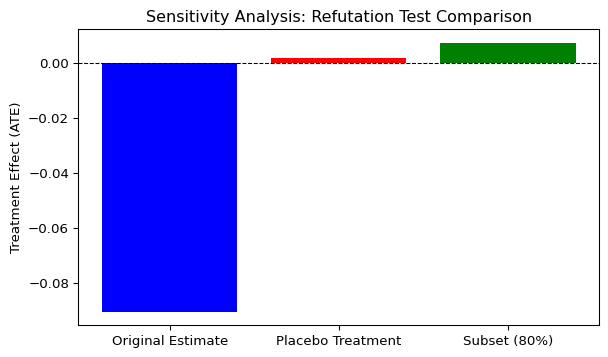

No distribution data available for Random Common Cause Refuter.
Sensitivity Analysis to Unobserved Confounding

Model Formula: visit ~ treatment + f3 + f6

Null hypothesis: q = 1 and reduce = True 

-- This means we are considering biases that reduce the absolute value of the current estimate.
-- The null hypothesis deemed problematic is H0:tau = 0.0 

Unadjusted Estimates of ' treatment ':
  Coef. estimate: 0.008
  Standard Error: 0.001
  t-value: 6.337 

Sensitivity Statistics:
  Partial R2 of treatment with outcome: 0.0
  Robustness Value, q = 1 : 0.014
  Robustness Value, q = 1 alpha = 0.05 : 0.01 

Verbal interpretation of sensitivity statistics:

-- Partial R2 of the treatment with the outcome: an extreme confounder (orthogonal to the covariates)  that explains 100% of the residual variance of the outcome, would need to explain at least 0.02 % of the residual variance of the treatment to fully account for the observed estimated effect.

-- Robustness Value, q = 1 : unobserved con

/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float


TypeError: advanced_tune_and_fit() got an unexpected keyword argument 'reuse_params'

In [ ]:
import statsmodels.formula.api as smf
from sensemakr import Sensemakr
from scipy.stats import kendalltau
 
corrected_confounders = ['f3', 'f6']
 
# Re-estimating the ATE with the corrected adjustment set
model_corr, identified_estimand_corr, estimate_corr = estimate_ate(
    criteo_df, 'treatment', 'visit', corrected_confounders
)
print("Corrected ATE (f3, f6 only):", estimate_corr.value)
print("Original ATE (all 12 features) was: 0.0067")
 
# Re-run of same refutation tests on this corrected estimate
refutation_results_corr = run_refutation_tests(model_corr, identified_estimand_corr, estimate_corr)
 
# Re-run of sensitivity analysis, benchmarked against f3 (the stronger of the two confounders)
ols_corr = smf.ols(formula="visit ~ treatment + f3 + f6", data=criteo_df).fit()
sensitivity_corr = Sensemakr(model=ols_corr, treatment="treatment", benchmark_covariates=["f3"], kd=[1, 2, 3])
sensitivity_corr.summary()
 
# Re-fitting CATE with the corrected adjustment set, reusing the already-tuned hyperparameters
cate_results_corr = advanced_tune_and_fit(
    criteo_df, criteo_df, corrected_confounders, 'treatment', 'visit',
    reuse_params={'num_leaves': 50, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
)
 
metrics_corr = evaluate_empirical_models(cate_results_corr, criteo_df, 'treatment', 'visit')
print(metrics_corr)


In [26]:
print("Treatment ratio:", criteo_df['treatment'].mean())
print("Visit (outcome) rate, treated:  ", criteo_df.loc[criteo_df.treatment==1, 'visit'].mean())
print("Visit (outcome) rate, untreated:", criteo_df.loc[criteo_df.treatment==0, 'visit'].mean())

Treatment ratio: 0.849675
Visit (outcome) rate, treated:   0.04911878071027157
Visit (outcome) rate, untreated: 0.03884916015300183


In [27]:
feature_cols = [f'f{i}' for i in range(12)]

# Using the new ensemble function on a sample
discovered_confounders_criteo = discover_confounders_ensemble(
    criteo_df.sample(n=5000, random_state=42), feature_cols, "treatment"
)
common_causes_criteo = discovered_confounders_criteo if discovered_confounders_criteo else feature_cols
print(f"Common causes used for Criteo: {common_causes_criteo}")

Running Causal Discovery Ensemble (PC, FCI, GES)...
X4 --> X2
X2 --> X6
X7 --> X4
X5 --> X6
X11 --> X5
X12 --> X5
X10 --> X9
X10 --> X12

Ensemble discovered confounders: []
Common causes used for Criteo: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


In [ ]:
# same estimate_ate function as synthetic data.
model_criteo, identified_estimand_criteo, estimate_criteo = estimate_ate(
    criteo_df, "treatment", "visit", common_causes_criteo
)

Estimated ATE: 0.0067


In [ ]:
# same refutation function
refutation_results_criteo = {}
refutation_results_criteo["placebo"] = model_criteo.refute_estimate(
    identified_estimand_criteo, estimate_criteo, method_name="placebo_treatment_refuter"
)
print(refutation_results_criteo["placebo"])

refutation_results_criteo["data_subset"] = model_criteo.refute_estimate(
    identified_estimand_criteo, estimate_criteo,
    method_name="data_subset_refuter", subset_fraction=0.8
)
print(refutation_results_criteo["data_subset"])

Refute: Use a Placebo Treatment
Estimated effect:0.006725
New effect:-8.000000000000037e-06
p value:0.9

Refute: Use a subset of data
Estimated effect:0.006725
New effect:0.00728825
p value:0.52



In [ ]:
# same CATE function as synthetic data.
print("Tuning and Fitting CATE Models on Criteo Data")


cate_results_criteo = advanced_tune_and_fit(criteo_df, criteo_df, feature_cols, "treatment", "visit")


criteo_df["estimated_cate"] = cate_results_criteo["Causal Forest"].flatten()

print("Distribution of estimated individual treatment effects:")
print(criteo_df["estimated_cate"].describe())

--- Tuning and Fitting CATE Models on Criteo Data ---
Running RandomizedSearchCV on base estimators...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folde

Best Regressor Params: {'num_leaves': 50, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best Classifier Params: {'num_leaves': 50, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Fitting Causal Forest...
Fitting X-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fold

Fitting S-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fitting Linear DML...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fol

Fitting T-Learner...
Distribution of estimated individual treatment effects:
count    200000.000000
mean          0.006556
std           0.021687
min          -0.168540
25%          -0.000106
50%           0.000462
75%           0.003733
max           0.437976
Name: estimated_cate, dtype: float64


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [31]:
top_decile = criteo_df['estimated_cate'].quantile(0.9)
bottom_decile = criteo_df['estimated_cate'].quantile(0.1)

print(f"Top 10% estimated effect: >= {top_decile:.4f}")
print(f"Bottom 10% estimated effect: <= {bottom_decile:.4f}")
print(f"\nActual observed visit rate (treated) in top decile:    "
      f"{criteo_df[(criteo_df.estimated_cate >= top_decile) & (criteo_df.treatment==1)]['visit'].mean():.4f}")
print(f"Actual observed visit rate (treated) in bottom decile: "
      f"{criteo_df[(criteo_df.estimated_cate <= bottom_decile) & (criteo_df.treatment==1)]['visit'].mean():.4f}")

Top 10% estimated effect: >= 0.0214
Bottom 10% estimated effect: <= -0.0006

Actual observed visit rate (treated) in top decile:    0.2984
Actual observed visit rate (treated) in bottom decile: 0.0684


Running Sensitivity Analysis on Criteo Data...
Sensitivity Analysis to Unobserved Confounding

Model Formula: visit ~ treatment + f0 + f1 + f2 + f3 + f4 + f5 + f6 + f7 + f8 + f9 + f10 + f11

Null hypothesis: q = 1 and reduce = True 

-- This means we are considering biases that reduce the absolute value of the current estimate.
-- The null hypothesis deemed problematic is H0:tau = 0.0 

Unadjusted Estimates of ' treatment ':
  Coef. estimate: 0.004
  Standard Error: 0.007
  t-value: 0.573 

Sensitivity Statistics:
  Partial R2 of treatment with outcome: 0.0
  Robustness Value, q = 1 : 0.008
  Robustness Value, q = 1 alpha = 0.05 : 0.0 

Verbal interpretation of sensitivity statistics:

-- Partial R2 of the treatment with the outcome: an extreme confounder (orthogonal to the covariates)  that explains 100% of the residual variance of the outcome, would need to explain at least 0.007 % of the residual variance of the treatment to fully account for the observed estimated effect.

-- Robus

/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (t_statistic ** 2 / (t_statistic ** 2 + dof))[0]  # extracts float


<Figure size 768x576 with 0 Axes>

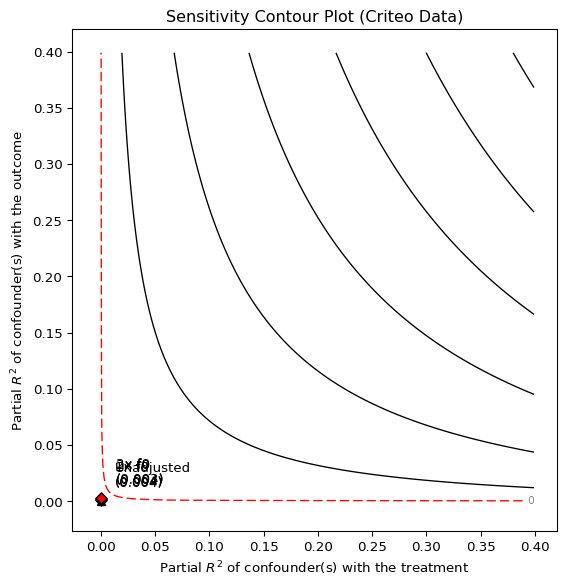

In [ ]:
import statsmodels.formula.api as smf
import sensemakr
import matplotlib.pyplot as plt

print("Running Sensitivity Analysis on Criteo Data")

# taking a 5000-row sample for speed
criteo_sample = criteo_df.sample(n=5000, random_state=42)

# trying to fit the linear model on the Criteo sample
formula = "visit ~ treatment + f0 + f1 + f2 + f3 + f4 + f5 + f6 + f7 + f8 + f9 + f10 + f11"
ols_model = smf.ols(formula, data=criteo_sample).fit()

# running the sensitivity analysis on 'treatment' against benchmark 'f0'
sense = sensemakr.Sensemakr(
    model=ols_model,
    treatment="treatment",
    benchmark_covariates="f0",
    kd=[1, 2, 3]
)

sense.summary()

plt.figure(figsize=(8, 6))
sense.plot()
plt.title("Sensitivity Contour Plot (Criteo Data)")
plt.show()

Generating Causal DAG Visualization for Criteo Data...


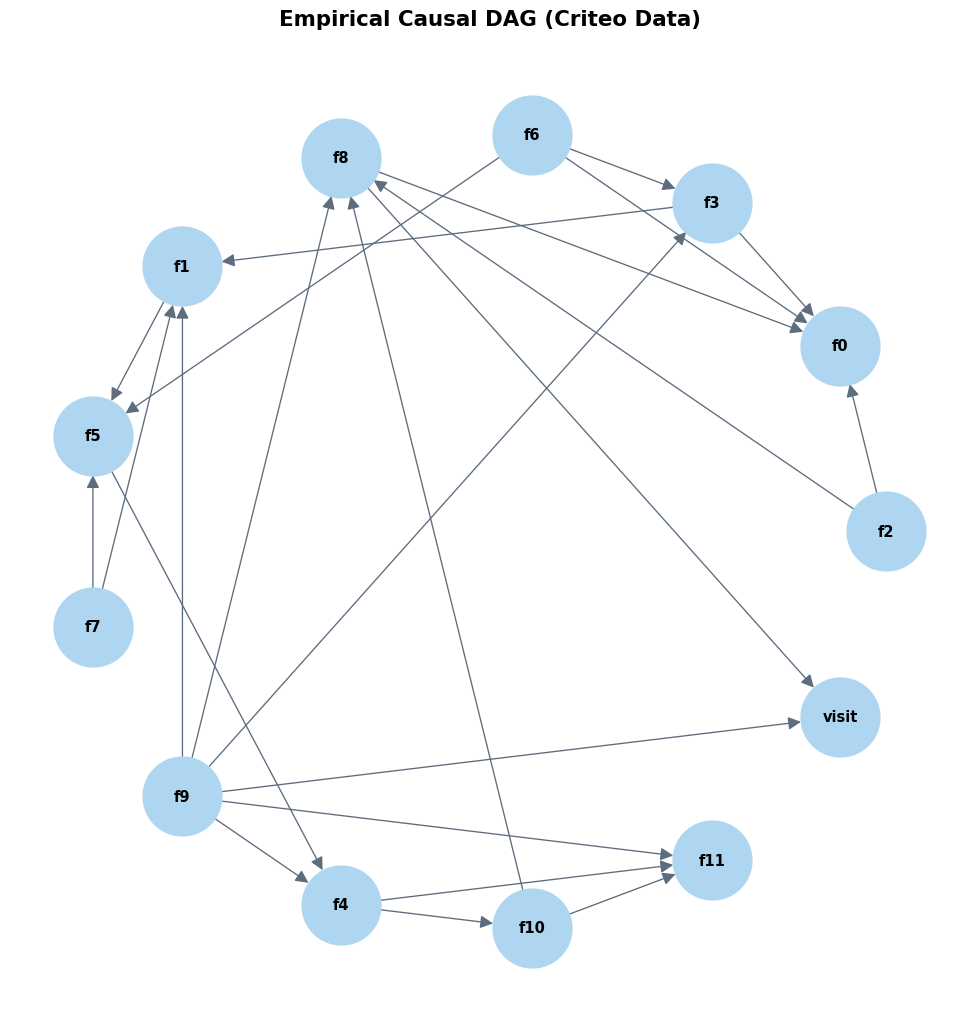

In [ ]:
criteo_dag_sample = criteo_df.sample(n=5000, random_state=42)

cg_criteo, mapped_vars_criteo = discover_full_causal_graph(
    criteo_dag_sample, feature_cols, "treatment", "visit"
)

plot_causal_graph(cg_criteo, mapped_vars_criteo)

---
## 7. End-to-end pipeline runner

- One function runs every step in order.
- It takes any dataset and the relevant column names.
- Discovery feeds directly into ATE estimation.
- ATE feeds directly into refutation checks.
- Refutation feeds directly into CATE estimation.
- This is the connected proof-of-pipeline cell.

STEP 1: Causal discovery
Running Causal Discovery Ensemble (PC, FCI, GES)...

Ensemble discovered confounders: []

STEP 2: ATE estimation
Estimated ATE: 0.3338

STEP 3: Refutation tests


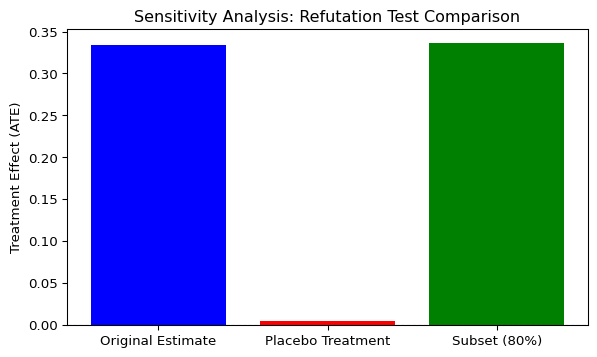

No distribution data available for Random Common Cause Refuter.

STEP 4: CATE estimation
Running RandomizedSearchCV on base estimators...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folde

Best Regressor Params: {'num_leaves': 31, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best Classifier Params: {'num_leaves': 31, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01}
Fitting Causal Forest...
Fitting X-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fold

Fitting S-Learner...
Fitting Linear DML...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fitting T-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fol

In [ ]:
def run_full_pipeline(df, feature_cols, treatment_col, outcome_col, do_discovery=True):
   
    print("\nSTEP 1: Causal discovery\n")
    if do_discovery:
        confounders = discover_confounders_ensemble(df, feature_cols, treatment_col)
        common_causes = confounders if confounders else feature_cols
    else:
        common_causes = feature_cols

    print("\n" + "\nSTEP 2: ATE estimation\n")
    model, identified_estimand, estimate = estimate_ate(df, treatment_col, outcome_col, common_causes)

    print("\n" +"\nSTEP 3: Refutation tests\n")
    refutations = run_refutation_tests(model, identified_estimand, estimate)

    print("\n" +"\nSTEP 4: CATE estimation\n")
    
    cate_results = advanced_tune_and_fit(df, df, feature_cols, treatment_col, outcome_col)

    return {
        "common_causes": common_causes,
        "model": model,
        "identified_estimand": identified_estimand,
        "estimate": estimate,
        "refutations": refutations,
        "cate_results": cate_results,
    }


pipeline_output = run_full_pipeline(df, ["age", "past_spend"], "T", "Y")

In [33]:
!pip install scikit-uplift -q

You should consider upgrading via the '/Users/shariq/Desktop/Dissertation/Program folder/causal_env/bin/python3 -m pip install --upgrade pip' command.


Running models to get predictions for comparison...
Running RandomizedSearchCV on base estimators...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folde

Best Regressor Params: {'num_leaves': 31, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01}
Best Classifier Params: {'num_leaves': 31, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01}
Fitting Causal Forest...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting X-Learner...


...

/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fitting Linear DML...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fol

Fitting T-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


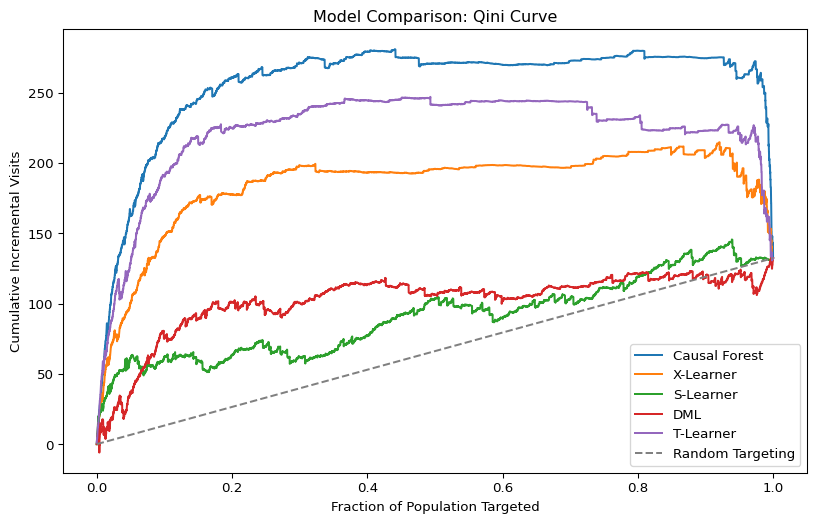

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_custom_qini(df, outcome_col, treatment_col, predictions_dict):
    plt.figure(figsize=(10, 6))

    for model_name, preds in predictions_dict.items():
        
        temp_df = pd.DataFrame({
            'y': df[outcome_col],
            't': df[treatment_col],
            'pred': preds
        })

        #sorting customers from highest predicted effect to lowest
        temp_df = temp_df.sort_values(by='pred', ascending=False)

        
        temp_df['cum_t'] = temp_df['t'].cumsum()
        temp_df['cum_c'] = (~temp_df['t'].astype(bool)).cumsum()

        #cumulative successes visits for both groups
        temp_df['cum_y_t'] = (temp_df['y'] * temp_df['t']).cumsum()
        temp_df['cum_y_c'] = (temp_df['y'] * (~temp_df['t'].astype(bool))).cumsum()

       
        # Qini formula
        qini = temp_df['cum_y_t'] - temp_df['cum_y_c'] * (temp_df['cum_t'] / temp_df['cum_c'].replace(0, 1))

        
        x_axis = np.arange(1, len(temp_df) + 1) / len(temp_df)

        plt.plot(x_axis, qini.values, label=model_name)

    
    plt.plot([0, 1], [0, qini.iloc[-1]], '--', color='gray', label='Random Targeting')

    plt.title("Model Comparison: Qini Curve")
    plt.xlabel("Fraction of Population Targeted")
    plt.ylabel("Cumulative Incremental Visits")
    plt.legend()
    plt.show()

print("Running models to get predictions for comparison")
sample_df = criteo_df.sample(n=10000, random_state=42)

# updating to use advanced_tune_and_fit
predictions = advanced_tune_and_fit(sample_df, sample_df, feature_cols, "treatment", "visit")

plot_custom_qini(sample_df, "visit", "treatment", predictions)

In [ ]:
#correlation check
print(f"Estimated CATE (Causal Forest) correlation with true ITE = {df['estimated_cate'].corr(df['true_ite']):.3f}")
print(f"Estimated CATE (X-Learner) correlation with true ITE = {df['estimated_cate_xlearner'].corr(df['true_ite']):.3f}")

Estimated CATE (Causal Forest) correlation with true ITE = 0.606
Estimated CATE (X-Learner) correlation with true ITE = 0.808


In [ ]:
import pandas as pd

file_name = "criteo-uplift-v2.1.csv" 

print("Loading full Criteo dataset")
criteo_full = pd.read_csv(file_name) 
print(f"Total rows loaded: {criteo_full.shape[0]}")

# Extracting 1-million row sample for tuning
criteo_tune_sample = criteo_full.sample(n=1000000, random_state=42)

# Defining features (f0 to f11)
feature_cols = [col for col in criteo_tune_sample.columns if col.startswith('f')]

print("Tuning Models on 1M Sample")

cate_results_sample = advanced_tune_and_fit(
    criteo_tune_sample, criteo_tune_sample, feature_cols, "treatment", "visit"
)

Loading full Criteo dataset...
Total rows loaded: 13979592
Sampling 1,000,000 rows for hyperparameter tuning...
--- Tuning Models on 1M Sample ---
Running RandomizedSearchCV on base estimators...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folde

Best Regressor Params: {'num_leaves': 50, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1}
Best Classifier Params: {'num_leaves': 50, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Fitting Causal Forest...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:

Fitting X-Learner...


...

/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fitting Linear DML...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program fol

Fitting T-Learner...


/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shariq/Desktop/Dissertation/Program folder/causal_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

def evaluate_empirical_models(df, predictions_dict, outcome_col, treatment_col):

    eval_results = []

    y = df[outcome_col].values
    t = df[treatment_col].values

    for model_name, preds in predictions_dict.items():
        preds = preds.flatten()

        
        order = np.argsort(-preds)
        y_sorted = y[order]
        t_sorted = t[order]

        n_total = len(y)
        n_t = np.cumsum(t_sorted)
        n_c = np.cumsum(1 - t_sorted)

        y_t = np.cumsum(y_sorted * t_sorted)
        y_c = np.cumsum(y_sorted * (1 - t_sorted))

        # 1 Qini Curve & AUC
        n_c_adj = np.where(n_c == 0, 1, n_c)
        qini_curve = y_t - y_c * (n_t / n_c_adj)
        qini_auc = np.trapezoid(qini_curve, dx=1/n_total)

        # 2 Uplift Curve & AUC
        n_t_adj = np.where(n_t == 0, 1, n_t)
        uplift_curve = (y_t / n_t_adj) - (y_c / n_c_adj)
        uplift_auc = np.trapezoid(uplift_curve, dx=1/n_total)

        # 3 Uplift @ 10%
        idx_10 = int(0.10 * n_total)
        uplift_10 = uplift_curve[idx_10]

        # 4 Uplift @ 30%
        idx_30 = int(0.30 * n_total)
        uplift_30 = uplift_curve[idx_30]

        # 5 Expected Response Rate (Top 20% targeted)
        idx_20 = int(0.20 * n_total)
        err = (y_t[idx_20] + (n_c[idx_20] * (y_c[idx_20] / n_c_adj[idx_20]))) / n_total

        eval_results.append({
            "Model": model_name,
            "Qini AUC": round(qini_auc, 4),
            "Uplift AUC": round(uplift_auc, 4),
            "Uplift@10%": round(uplift_10, 4),
            "Uplift@30%": round(uplift_30, 4),
            "Expected Response Rate": round(err, 4)
        })

    summary_df = pd.DataFrame(eval_results)
    return summary_df

# Evaluating models on 1 million row Criteo sample
criteo_metrics_table = evaluate_empirical_models(
    criteo_tune_sample,        
    cate_results_sample,       
    outcome_col="visit", 
    treatment_col="treatment"
)

print("\nEmpirical model comparison across 5 metrics")
print(criteo_metrics_table.to_string(index=False))


=== Empirical Model Comparison Across 5 Metrics ===
        Model   Qini AUC  Uplift AUC  Uplift@10%  Uplift@30%  Expected Response Rate
Causal Forest 11251.5699      0.0554      0.1318      0.0425                  0.0418
    X-Learner 10298.9041      0.0475      0.0962      0.0407                  0.0349
    S-Learner  7623.8535      0.0301      0.0567      0.0293                  0.0424
          DML  7530.4849      0.0292      0.0548      0.0296                  0.0408
    T-Learner 11062.2880      0.0510      0.1075      0.0439                  0.0344


In [ ]:
import numpy as np
from scipy.stats import kendalltau
from econml.dml import CausalForestDML
 
feature_cols = [c for c in criteo_df.columns if c.startswith('f')]
X = criteo_df[feature_cols].values
T = criteo_df['treatment'].values
Y = criteo_df['visit'].values
 
def fit_cf(X_, T_, Y_, n_estimators=100, seed=42):
    cf = CausalForestDML(n_estimators=n_estimators, max_depth=10,
                          discrete_treatment=True, random_state=seed)
    cf.fit(Y_, T_, X=X_)
    return cf.effect(X_)
 
# Baseline CATE
preds_baseline = fit_cf(X, T, Y)
 
# Placebo test
rng = np.random.RandomState(42)
T_placebo = rng.permutation(T)
preds_placebo = fit_cf(X, T_placebo, Y)
tau_placebo, _ = kendalltau(preds_placebo, preds_baseline)
print("Placebo Kendall's Tau vs baseline ranking:", tau_placebo)
 
# Data-subset test: refit on 80% subsample
idx80 = rng.choice(len(criteo_df), size=int(0.8 * len(criteo_df)), replace=False)
preds_subset = fit_cf(X[idx80], T[idx80], Y[idx80])
tau_subset, _ = kendalltau(preds_subset, preds_baseline[idx80])
print("Subset (80%) Kendall's Tau vs baseline ranking:", tau_subset)
 
corrs = [(f, abs(np.corrcoef(criteo_df[f].values, T)[0, 1])) for f in feature_cols]
corrs.sort(key=lambda x: -x[1])
ranked_features = [f for f, _ in corrs]
print("Features ranked by correlation with treatment:", ranked_features)
 
for kappa in [0, 1, 2, 3]:
    kept_features = ranked_features[kappa:]
    X_reduced = criteo_df[kept_features].values
    preds_kappa = fit_cf(X_reduced, T, Y)
    tau_kappa, _ = kendalltau(preds_kappa, preds_baseline)
    print(f"kappa={kappa} (top-{kappa} treatment-correlated features withheld): "
          f"Kendall's Tau vs full-covariate baseline =", tau_kappa)


Placebo Kendall's Tau vs baseline ranking: 0.02513079351196595
